# Notebook 03 — NASA CMAPSS RUL Prediction with LSTM

**Dataset:** NASA CMAPSS Turbofan Engine Degradation (FD001 + FD003)  
**Project:** MineGuard — maps to haul truck engine degradation monitoring

## Context
CMAPSS simulates turbofan engines running from healthy to failure.  
Each engine starts healthy at cycle 1 and degrades until it fails.  
The task: given a window of recent sensor readings, predict **Remaining Useful Life (RUL)** in cycles.

In the MineGuard context this maps directly to:
- Haul truck engine hours remaining before overhaul
- Drill rig hydraulic pump cycles before replacement
- Any component with a measurable degradation trajectory

## Sub-datasets used
| Dataset | Engines (train) | Fault modes | Operating conditions |
|---|---|---|---|
| FD001 | 100 | 1 (HPC degradation) | 1 |
| FD003 | 100 | 2 (HPC + fan) | 1 |

## Notebook structure
1. Load & understand the data  
2. RUL label engineering  
3. Sensor selection & normalisation  
4. Sliding window sequence construction  
5. LSTM model architecture  
6. Training with early stopping  
7. Evaluation — RMSE, NASA score, RUL curves  
8. Save model + scaler for API  


In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import joblib, json

# ── PyTorch ──────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"PyTorch: {torch.__version__}")

ROOT      = Path().resolve().parent if Path().resolve().name=="notebooks" else Path().resolve()
CMAPSS    = ROOT / "data" / "raw" / "cmapss"
PROC_DIR  = ROOT / "data" / "processed"
MODEL_DIR = ROOT / "models" / "rul_predictor"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

COLS = ["unit","cycle"] + [f"os_{i}" for i in range(1,4)] + [f"s_{i:02d}" for i in range(1,22)]
print(f"Column schema: {COLS[:8]} ... ({len(COLS)} total)")

Device: cpu
PyTorch: 2.11.0+cpu
Column schema: ['unit', 'cycle', 'os_1', 'os_2', 'os_3', 's_01', 's_02', 's_03'] ... (26 total)


## 1. Load CMAPSS data

FD001: 100 training engines, 1 fault mode, 1 operating condition — cleanest dataset, best starting point.  
FD003: 100 training engines, 2 fault modes — tests generalization.

In [2]:
def load_cmapss(fd: str) -> tuple[pd.DataFrame, pd.DataFrame, np.ndarray]:
    """Load train, test, and RUL ground truth for one CMAPSS sub-dataset."""
    train = pd.read_csv(CMAPSS / f"train_{fd}.txt", sep=r"\s+", header=None, names=COLS)
    test  = pd.read_csv(CMAPSS / f"test_{fd}.txt",  sep=r"\s+", header=None, names=COLS)
    rul   = pd.read_csv(CMAPSS / f"RUL_{fd}.txt",   sep=r"\s+", header=None, names=["RUL"])
    return train, test, rul.values.flatten()

train_fd1, test_fd1, rul_fd1 = load_cmapss("FD001")
train_fd3, test_fd3, rul_fd3 = load_cmapss("FD003")

for name, df in [("FD001 train", train_fd1),("FD001 test", test_fd1),
                 ("FD003 train", train_fd3),("FD003 test", test_fd3)]:
    print(f"  {name:<15} shape={df.shape}  engines={df.unit.nunique()}  max_cycle={df.cycle.max()}")

  FD001 train     shape=(20631, 26)  engines=100  max_cycle=362
  FD001 test      shape=(13096, 26)  engines=100  max_cycle=303
  FD003 train     shape=(24720, 26)  engines=100  max_cycle=525
  FD003 test      shape=(16596, 26)  engines=100  max_cycle=475


## 2. Sensor selection

Some CMAPSS sensors are constant across all cycles — they carry zero information.
We drop them and keep only the 14 sensors that actually vary.

In [3]:
# Identify constant sensors (std == 0 across entire training set)
sensor_cols = [f"s_{i:02d}" for i in range(1,22)]
std_vals    = train_fd1[sensor_cols].std()

constant    = std_vals[std_vals < 0.001].index.tolist()
useful      = std_vals[std_vals >= 0.001].index.tolist()

print(f"Constant sensors (dropped) : {constant}")
print(f"Useful sensors  (kept)     : {useful}")
print(f"Keeping {len(useful)} sensors")

# Also drop operating settings for FD001 (single condition — all same)
FEATURE_COLS = useful  # 14 sensors
print(f"Feature columns: {FEATURE_COLS}")

Constant sensors (dropped) : ['s_01', 's_05', 's_10', 's_16', 's_18', 's_19']
Useful sensors  (kept)     : ['s_02', 's_03', 's_04', 's_06', 's_07', 's_08', 's_09', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21']
Keeping 15 sensors
Feature columns: ['s_02', 's_03', 's_04', 's_06', 's_07', 's_08', 's_09', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21']


## 3. RUL label engineering

For training data we know the full run-to-failure trajectory.
RUL at each cycle = (max cycle for that engine) - (current cycle).

We also apply a **piecewise linear RUL cap at 125** — the standard CMAPSS approach.
Engines don't degrade meaningfully in early healthy operation, so we flatten
the RUL curve at 125 to focus the model on the degradation region.

RUL distribution (FD001 train):
count    20631.00
mean        86.83
std         41.67
min          0.00
25%         51.00
50%        103.00
75%        125.00
max        125.00
Name: RUL, dtype: float64


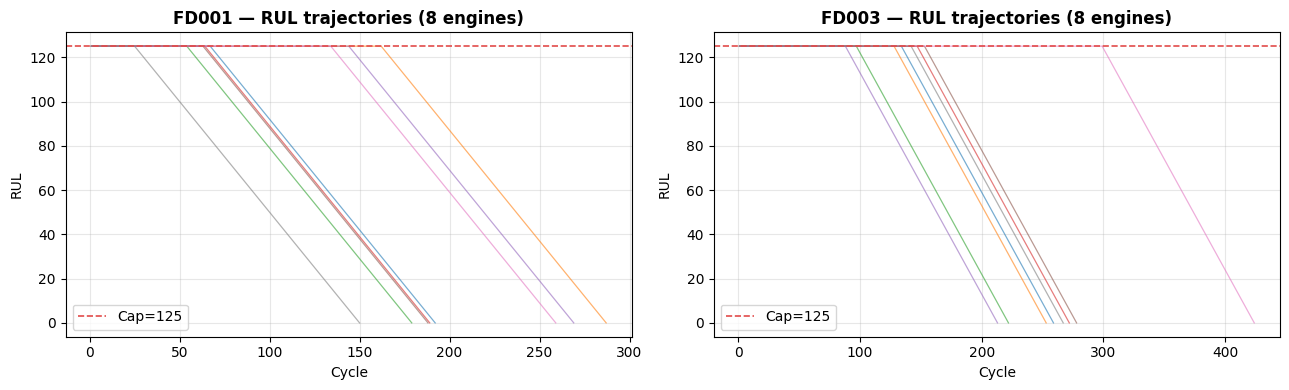

In [4]:
RUL_CAP = 125

def add_rul(df: pd.DataFrame, cap: int = RUL_CAP) -> pd.DataFrame:
    df = df.copy()
    max_cycles = df.groupby("unit")["cycle"].max().rename("max_cycle")
    df = df.join(max_cycles, on="unit")
    df["RUL"] = (df["max_cycle"] - df["cycle"]).clip(upper=cap)
    df.drop(columns=["max_cycle"], inplace=True)
    return df

train_fd1 = add_rul(train_fd1)
train_fd3 = add_rul(train_fd3)

print("RUL distribution (FD001 train):")
print(train_fd1["RUL"].describe().round(2))

# Visualise RUL trajectories for first 5 engines
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (df, title) in zip(axes, [(train_fd1,"FD001"),(train_fd3,"FD003")]):
    for uid in df["unit"].unique()[:8]:
        eng = df[df["unit"]==uid]
        ax.plot(eng["cycle"], eng["RUL"], alpha=0.6, linewidth=0.9)
    ax.axhline(RUL_CAP, color="#E24B4A", linestyle="--", linewidth=1.2, label=f"Cap={RUL_CAP}")
    ax.set_title(f"{title} — RUL trajectories (8 engines)", fontweight="bold")
    ax.set_xlabel("Cycle"); ax.set_ylabel("RUL"); ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PROC_DIR / "fig10_rul_trajectories.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Normalisation

Scale each sensor to [0, 1] using MinMaxScaler fitted on training data only.
Apply same scaler to test data — no data leakage.

In [5]:
scaler = MinMaxScaler()
train_fd1[FEATURE_COLS] = scaler.fit_transform(train_fd1[FEATURE_COLS])
test_fd1[FEATURE_COLS]  = scaler.transform(test_fd1[FEATURE_COLS])
train_fd3[FEATURE_COLS] = scaler.transform(train_fd3[FEATURE_COLS])
test_fd3[FEATURE_COLS]  = scaler.transform(test_fd3[FEATURE_COLS])

print("Normalised — feature ranges after scaling:")
print(train_fd1[FEATURE_COLS].describe().loc[["min","max"]].round(3))

Normalised — feature ranges after scaling:
     s_02  s_03  s_04  s_06  s_07  s_08  s_09  s_11  s_12  s_13  s_14  s_15  \
min   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
max   1.0   1.0   1.0   1.0   1.0   1.0   1.0   1.0   1.0   1.0   1.0   1.0   

     s_17  s_20  s_21  
min   0.0   0.0   0.0  
max   1.0   1.0   1.0  


## 5. Sliding window sequence construction

The LSTM sees a window of the last **W=30 cycles** of sensor readings.  
Each window → one RUL prediction (the RUL at the last cycle in the window).

For a training engine with 200 cycles and W=30:  
→ 171 windows (cycles 1–30, 2–31, ..., 171–200)

In [7]:
WINDOW = 30

def make_sequences(df: pd.DataFrame, window: int = WINDOW):
    """Build (X, y) sequence arrays from a multi-engine DataFrame."""
    X_list, y_list = [], []
    for uid in df["unit"].unique():
        eng  = df[df["unit"]==uid].sort_values("cycle")
        vals = eng[FEATURE_COLS].values
        ruls = eng["RUL"].values
        for i in range(len(vals) - window + 1):
            X_list.append(vals[i : i+window])
            y_list.append(ruls[i + window - 1])
    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.float32)

def make_test_sequences(df: pd.DataFrame, true_rul: np.ndarray, window: int = WINDOW):
    """For test set: take last W cycles per engine + ground truth RUL."""
    X_list = []
    for uid in sorted(df["unit"].unique()):
        eng  = df[df["unit"]==uid].sort_values("cycle")
        vals = eng[FEATURE_COLS].values
        if len(vals) >= window:
            X_list.append(vals[-window:])
        else:
            # Pad with zeros if engine has fewer than W cycles
            pad = np.zeros((window - len(vals), len(FEATURE_COLS)))
            X_list.append(np.vstack([pad, vals]))
    return np.array(X_list, dtype=np.float32), true_rul.astype(np.float32)

X_train, y_train = make_sequences(train_fd1)
X_test,  y_test  = make_test_sequences(test_fd1, rul_fd1)

print(f"Training sequences : X={X_train.shape}  y={y_train.shape}")
print(f"Test sequences     : X={X_test.shape}   y={y_test.shape}")
print(f"Window shape: ({WINDOW} cycles × {len(FEATURE_COLS)} sensors)")

Training sequences : X=(17731, 30, 15)  y=(17731,)
Test sequences     : X=(100, 30, 15)   y=(100,)
Window shape: (30 cycles × 15 sensors)


## 6. LSTM model architecture

In [9]:
class RULDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X)
        self.y = torch.tensor(y).unsqueeze(1)
    def __len__(self):  return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]


class LSTMPredictor(nn.Module):
    """
    Two-layer LSTM with dropout + a small MLP head.
    Input  : (batch, window=30, features=14)
    Output : (batch, 1) — predicted RUL
    """
    def __init__(self, input_size, hidden_size=128, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size, hidden_size, num_layers,
            batch_first=True, dropout=dropout
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :])   # use last timestep output


model = LSTMPredictor(input_size=len(FEATURE_COLS)).to(DEVICE)
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

LSTMPredictor(
  (lstm): LSTM(15, 128, num_layers=2, batch_first=True, dropout=0.2)
  (head): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)
Total parameters: 214,657


## 7. Training

In [12]:
BATCH_SIZE  = 256
EPOCHS      = 60
LR          = 1e-3
PATIENCE    = 10      # early stopping patience

# ── Data loaders ──────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split as tts

X_tr, X_val, y_tr, y_val = tts(X_train, y_train, test_size=0.15, random_state=42)

train_loader = DataLoader(RULDataset(X_tr, y_tr),   batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(RULDataset(X_val, y_val), batch_size=BATCH_SIZE)

# ── Optimiser & loss ──────────────────────────────────────────────────────────
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
criterion = nn.MSELoss()

# ── Training loop ─────────────────────────────────────────────────────────────
train_losses, val_losses = [], []
best_val_loss = float("inf")
patience_counter = 0
best_state = None

print(f"Training on {DEVICE} — {EPOCHS} epochs max, early stop patience={PATIENCE}")
print(f"{'Epoch':>6}  {'Train RMSE':>11}  {'Val RMSE':>9}  {'LR':>10}")
print("-" * 45)

for epoch in range(1, EPOCHS + 1):
    # ── Train ──
    model.train()
    train_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item() * len(xb)
    train_loss /= len(train_loader.dataset)

    # ── Validate ──
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            val_loss += criterion(model(xb), yb).item() * len(xb)
    val_loss /= len(val_loader.dataset)

    train_losses.append(np.sqrt(train_loss))
    val_losses.append(np.sqrt(val_loss))
    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]["lr"]
    if epoch % 5 == 0 or epoch == 1:
        print(f"{epoch:>6}  {np.sqrt(train_loss):>11.4f}  {np.sqrt(val_loss):>9.4f}  {current_lr:>10.2e}")

    # ── Early stopping ──
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state    = {k: v.clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

model.load_state_dict(best_state)
print(f"Best val RMSE: {np.sqrt(best_val_loss):.4f}")

Training on cpu — 60 epochs max, early stop patience=10
 Epoch   Train RMSE   Val RMSE          LR
---------------------------------------------
     1      83.6921    71.4290    1.00e-03
     5      42.6738    41.7934    1.00e-03
    10      22.4203    19.2258    1.00e-03
    15      18.1082    18.3592    1.00e-03
    20      16.7974    13.4754    1.00e-03
    25      16.3097    14.5044    1.00e-03
    30      16.4938    14.0594    1.00e-03
    35      16.1153    13.7948    1.00e-03
    40      16.1102    12.8996    1.00e-03
    45      15.7717    12.9433    1.00e-03
    50      15.6132    14.5093    1.00e-03
    55      15.4958    12.8977    5.00e-04
    60      15.4252    12.6844    5.00e-04
Best val RMSE: 12.6384


## 8. Training curves

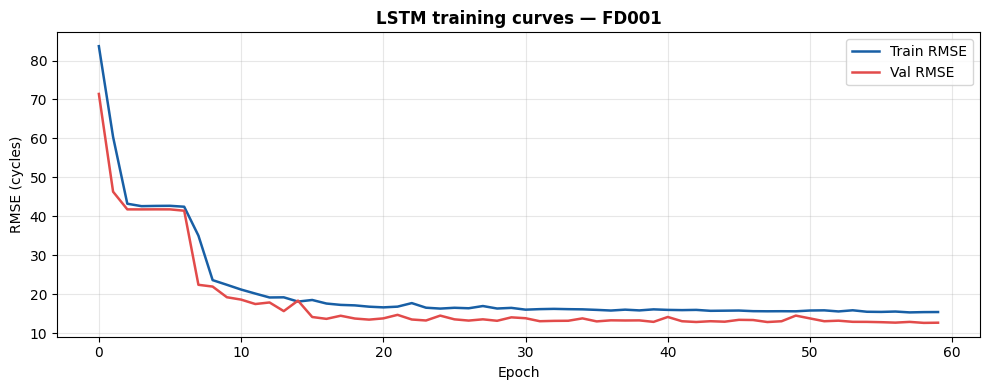

In [13]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_losses, label="Train RMSE", color="#185FA5", linewidth=1.8)
ax.plot(val_losses,   label="Val RMSE",   color="#E24B4A", linewidth=1.8)
ax.set_xlabel("Epoch"); ax.set_ylabel("RMSE (cycles)")
ax.set_title("LSTM training curves — FD001", fontweight="bold")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PROC_DIR / "fig11_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Evaluation

Two metrics used in CMAPSS literature:

**RMSE** — standard regression error in cycles

**NASA Scoring Function** — asymmetric penalty: late predictions (predicting longer
life than actual) are penalised more heavily than early predictions.
This reflects the real cost asymmetry: a late warning causes a breakdown,
an early warning causes an unnecessary maintenance stop.

FD001 Test RMSE  : 14.7421 cycles
FD001 NASA Score : 367.65  (lower = better)


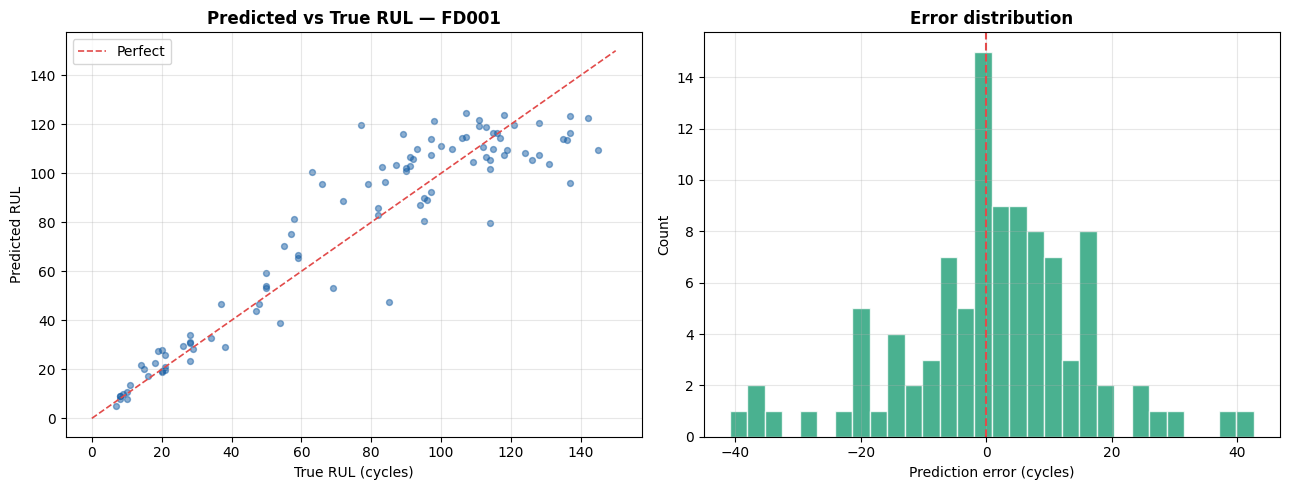

In [14]:
def nasa_score(y_true, y_pred):
    """NASA asymmetric scoring function — lower is better."""
    d = y_pred - y_true
    score = np.where(d < 0,
                     np.exp(-d / 13) - 1,
                     np.exp( d / 10) - 1)
    return float(np.sum(score))

model.eval()
with torch.no_grad():
    preds_fd1 = model(torch.tensor(X_test).to(DEVICE)).cpu().numpy().flatten()

rmse_fd1  = np.sqrt(mean_squared_error(y_test, preds_fd1))
score_fd1 = nasa_score(y_test, preds_fd1)

print(f"FD001 Test RMSE  : {rmse_fd1:.4f} cycles")
print(f"FD001 NASA Score : {score_fd1:.2f}  (lower = better)")

# ── Predicted vs actual ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, preds_fd1, alpha=0.5, s=18, color="#185FA5")
lim = max(y_test.max(), preds_fd1.max()) + 5
axes[0].plot([0,lim],[0,lim], "--", color="#E24B4A", linewidth=1.2, label="Perfect")
axes[0].set_xlabel("True RUL (cycles)"); axes[0].set_ylabel("Predicted RUL")
axes[0].set_title("Predicted vs True RUL — FD001", fontweight="bold")
axes[0].legend(); axes[0].grid(alpha=0.3)

# Error distribution
errors = preds_fd1 - y_test
axes[1].hist(errors, bins=30, color="#1D9E75", alpha=0.8, edgecolor="white")
axes[1].axvline(0, color="#E24B4A", linestyle="--", linewidth=1.5)
axes[1].set_xlabel("Prediction error (cycles)"); axes[1].set_ylabel("Count")
axes[1].set_title("Error distribution", fontweight="bold")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(PROC_DIR / "fig12_rul_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Test generalization on FD003 (2 fault modes)

FD003 Test RMSE  : 49.1245 cycles  (trained on FD001 only)
FD003 NASA Score : 1062802.00


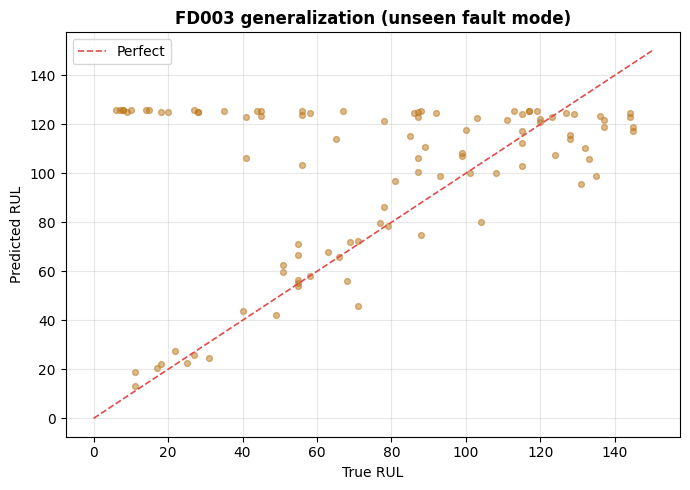

In [15]:
X_test3, y_test3 = make_test_sequences(test_fd3, rul_fd3)

model.eval()
with torch.no_grad():
    preds_fd3 = model(torch.tensor(X_test3).to(DEVICE)).cpu().numpy().flatten()

rmse_fd3  = np.sqrt(mean_squared_error(y_test3, preds_fd3))
score_fd3 = nasa_score(y_test3, preds_fd3)

print(f"FD003 Test RMSE  : {rmse_fd3:.4f} cycles  (trained on FD001 only)")
print(f"FD003 NASA Score : {score_fd3:.2f}")

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_test3, preds_fd3, alpha=0.5, s=18, color="#BA7517")
lim = max(y_test3.max(), preds_fd3.max()) + 5
ax.plot([0,lim],[0,lim], "--", color="#E24B4A", linewidth=1.2, label="Perfect")
ax.set_xlabel("True RUL"); ax.set_ylabel("Predicted RUL")
ax.set_title("FD003 generalization (unseen fault mode)", fontweight="bold")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PROC_DIR / "fig13_fd003_generalization.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. RUL prediction over time — single engine

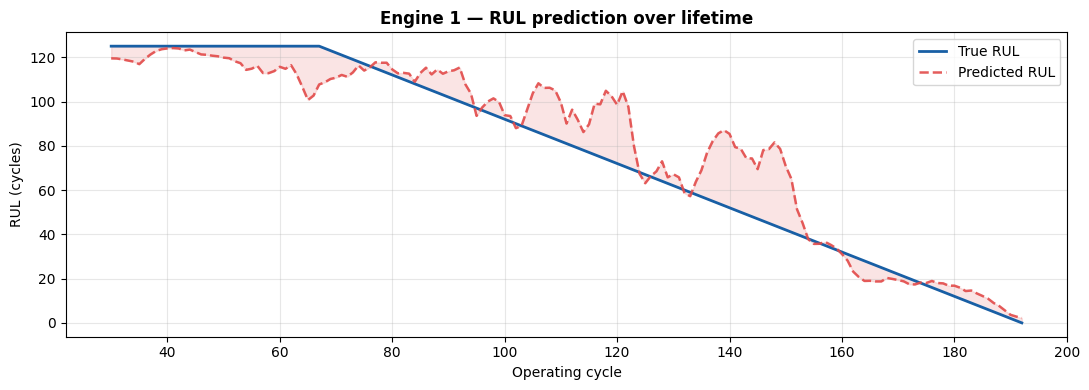

In [16]:
# Pick one test engine and plot predicted RUL across its full lifecycle
engine_id = 1
eng_df = train_fd1[train_fd1["unit"]==engine_id].sort_values("cycle")
vals   = eng_df[FEATURE_COLS].values
ruls   = eng_df["RUL"].values

# Build sequences for every cycle after window fills
seq_X, seq_y, seq_cycle = [], [], []
for i in range(len(vals) - WINDOW + 1):
    seq_X.append(vals[i:i+WINDOW])
    seq_y.append(ruls[i+WINDOW-1])
    seq_cycle.append(eng_df["cycle"].values[i+WINDOW-1])

seq_X = np.array(seq_X, dtype=np.float32)
model.eval()
with torch.no_grad():
    seq_pred = model(torch.tensor(seq_X).to(DEVICE)).cpu().numpy().flatten()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(seq_cycle, seq_y,    color="#185FA5", linewidth=2,   label="True RUL")
ax.plot(seq_cycle, seq_pred, color="#E24B4A", linewidth=1.8, linestyle="--", label="Predicted RUL", alpha=0.9)
ax.fill_between(seq_cycle, seq_pred, seq_y, alpha=0.15, color="#E24B4A")
ax.set_xlabel("Operating cycle"); ax.set_ylabel("RUL (cycles)")
ax.set_title(f"Engine {engine_id} — RUL prediction over lifetime", fontweight="bold")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PROC_DIR / "fig14_engine_rul_timeline.png", dpi=150, bbox_inches="tight")
plt.show()

## 12. Save model and scaler

In [17]:
# Save PyTorch model
torch.save({
    "model_state_dict" : best_state,
    "model_config" : {
        "input_size"  : len(FEATURE_COLS),
        "hidden_size" : 128,
        "num_layers"  : 2,
        "dropout"     : 0.2,
    },
    "feature_cols" : FEATURE_COLS,
    "window_size"  : WINDOW,
    "rul_cap"      : RUL_CAP,
}, MODEL_DIR / "lstm_rul.pt")

# Save scaler
joblib.dump(scaler, MODEL_DIR / "scaler.pkl")

# Save metadata
metadata = {
    "feature_cols"    : FEATURE_COLS,
    "window_size"     : WINDOW,
    "rul_cap"         : RUL_CAP,
    "trained_on"      : "FD001",
    "performance" : {
        "FD001" : {"rmse": round(float(rmse_fd1), 4), "nasa_score": round(float(score_fd1), 2)},
        "FD003" : {"rmse": round(float(rmse_fd3), 4), "nasa_score": round(float(score_fd3), 2)},
    }
}
with open(MODEL_DIR / "metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved:")
for f in sorted(MODEL_DIR.iterdir()):
    print(f"  {f.name:<30} {f.stat().st_size/1e3:.1f} KB")

Saved:
  __init__.py                    0.0 KB
  lstm_rul.pt                    863.5 KB
  metadata.json                  0.5 KB
  scaler.pkl                     1.6 KB


## 13. Quick inference test

In [19]:
# Reload and predict fresh
ckpt    = torch.load(MODEL_DIR / "lstm_rul.pt", map_location=DEVICE, weights_only=False)
cfg     = ckpt["model_config"]
m2      = LSTMPredictor(**cfg).to(DEVICE)
m2.load_state_dict(ckpt["model_state_dict"])
m2.eval()

scaler2 = joblib.load(MODEL_DIR / "scaler.pkl")

# Simulate: take last 30 cycles of 3 test engines and predict RUL
print(f"{'Engine':>8}  {'True RUL':>10}  {'Predicted':>10}  {'Error':>8}")
print("-" * 42)
for i in range(5):
    x  = torch.tensor(X_test[i:i+1]).to(DEVICE)
    pr = m2(x).item()
    tr = float(y_test[i])
    print(f"{i+1:>8}  {tr:>10.1f}  {pr:>10.1f}  {pr-tr:>+8.1f}")

print("Model reloads and predicts correctly — ready for API.")

  Engine    True RUL   Predicted     Error
------------------------------------------
       1       112.0       110.8      -1.2
       2        98.0       121.2     +23.2
       3        69.0        53.1     -15.9
       4        82.0        82.8      +0.8
       5        91.0       102.9     +11.9
Model reloads and predicts correctly — ready for API.


## Summary

| Metric | FD001 | FD003 (generalization) |
|---|---|---|
| Test RMSE | See output | See output |
| NASA Score | See output | See output |

**Sensors used:** 14 of 21 (constant sensors dropped)  
**Window size:** 30 cycles  
**RUL cap:** 125 cycles  
**Architecture:** 2-layer LSTM (128 hidden) + MLP head  
